# XGBoost with RF Feature Selection + SHAP Analysis

In [49]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
import shap

In [50]:

# Load your dataset
data = pd.read_csv("mode_choice_data.csv")

# Clean column names
data.columns = data.columns.str.strip().str.replace('\t', '')

target_col = 'travel_mode'

# Adjust labels to 0-based
data[target_col] = data[target_col] - 1

X = data.drop(columns=[target_col, 'id'])
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Data loaded successfully")

Data loaded successfully


In [57]:

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Select top 30 features
top_30_features = rf_importances["feature"].head(30).tolist()

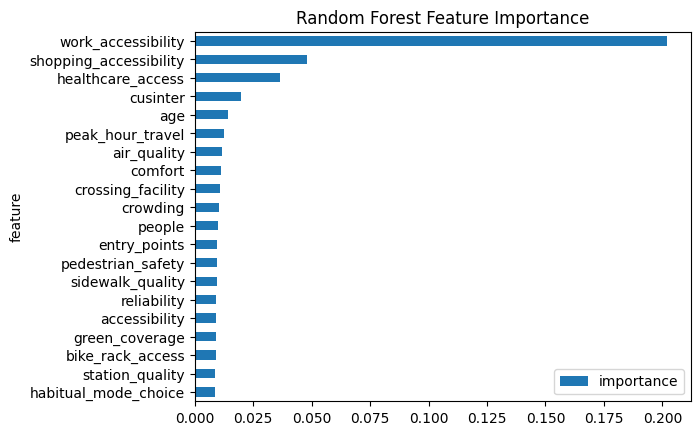

In [52]:
rf_importances.head(20).plot(
    kind='barh',
    x='feature',
    y='importance',
    title='Random Forest Feature Importance'
)
plt.gca().invert_yaxis()
plt.show()

In [56]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train[top_30_features], y_train)

y_pred = model.predict(X_test[top_30_features])
acc = accuracy_score(y_test, y_pred)

print(f"XGBoost Accuracy with Top 30 Features: {acc*100:.2f}%")

XGBoost Accuracy with Top 30 Features: 90.91%


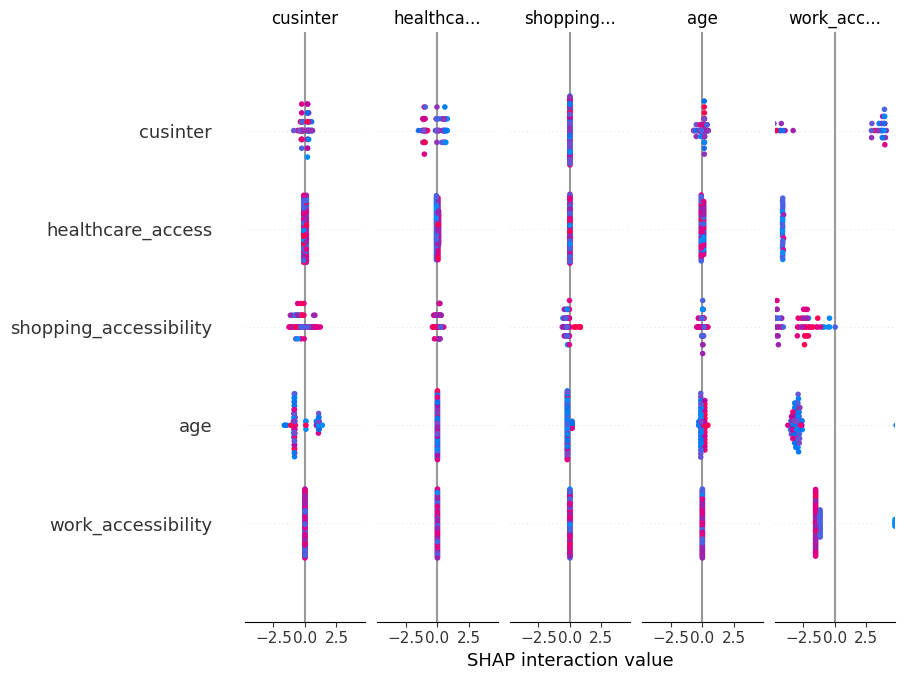

In [54]:

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[top_30_features])

# SHAP summary plot
shap.summary_plot(shap_values, X_test[top_30_features])


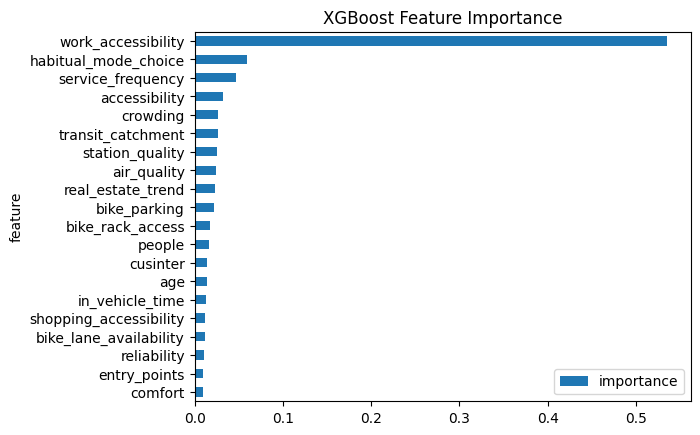

In [55]:
# Create importance DataFrame
xgb_importance_df = pd.DataFrame({
     "feature": top_30_features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

xgb_importance_df.head(20).plot(
    kind='barh',
    x='feature',
    y='importance',
    title='XGBoost Feature Importance'
)
plt.gca().invert_yaxis()
plt.show()